# 🧬 Xây dựng PINN cho Phương trình Vi phân với JAX (`vmap` + `grad`)

Bài toán đặt ra là giải phương trình vi phân thường (ODE) mô tả quá trình giảm mũ:
$$\frac{du}{dt} = -k \cdot u(t), \quad u(0) = 1, \quad k = 1.0$$

Nghiệm giải tích (Analytic solution) của phương trình này là: $u(t) = e^{-t}$.

---

## 1. Điểm cốt lõi: Sự vượt trội của JAX vs PyTorch trong PINN

Khi tính toán số dư vật lý (Physics Residual) trong PINN, ta cần tính đạo hàm của mô hình theo thời gian $\frac{du}{dt}$ tại một tập hợp các điểm phối trí (collocation points).

* **Trong PyTorch (Cồng kềnh):** PyTorch yêu cầu bạn phải dùng `torch.autograd.grad`, cấu hình các cờ `create_graph=True`, và phải truyền vào một vectơ `grad_outputs=torch.ones_like(...)` để khớp số chiều của Batch. Việc ép chiều (broadcasting) và quản lý đồ thị tính toán rất dễ sót lỗi.
* **Trong JAX (Sạch sẽ & Tối ưu):** Bạn chỉ cần định nghĩa hàm tính đạo hàm cho **đúng 1 điểm đơn lẻ $t$** bằng `jax.grad`. Sau đó, dùng `vmap` để tự động vectơ hóa qua toàn bộ Batch. Code hoàn toàn trùng khớp với công thức toán học lý thuyết.

In [ ]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import optax
import numpy as np
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(42)
k = 1.0
T_END = 5.0
print(f'JAX devices: {jax.devices()}')

JAX devices: [CudaDevice(id=0)]


# 1. PINN Model (Flax)

In [ ]:
class PINN(nn.Module):
    hidden: int = 64
    n_layers: int = 3

    @nn.compact
    def __call__(self, t):
        """t: scalar (single time point)."""
        x = t.reshape(1)  # (1,)
        for _ in range(self.n_layers):
            x = nn.Dense(self.hidden)(x)
            x = nn.tanh(x)
        return nn.Dense(1)(x)[0]  # scalar output

model = PINN()
key, init_key = jax.random.split(key)
params = model.init(init_key, jnp.array(0.0))['params']
print('PINN initialized.')

PINN initialized.


## 2. Số dư vật lý — Phương pháp JAX (Physics Residual — The JAX Way)

Trong các mô hình mạng nơ-ron thông tin vật lý (PINNs), việc tính toán số dư phương trình vi phân (Physics Residual) đòi hỏi ta phải lấy đạo hàm của đầu ra mạng nơ-ron theo các biến đầu vào (như thời gian $t$ hoặc không gian $x$).

---

### ⚖️ So sánh kiến trúc: PyTorch vs JAX

#### 🟥 Cách làm truyền thống trong PyTorch
PyTorch quản lý đạo hàm dựa trên đồ thị tính toán của cả một Batch dữ liệu (Batch-level graph). Do đó, để tính đạo hàm $\frac{du}{dt}$, bạn bắt buộc phải dùng hàm `torch.autograd.grad`.
* Bạn phải truyền một vectơ mồi `grad_outputs=torch.ones_like(u)` để khớp số chiều.
* Phải bật cờ `create_graph=True` để giữ lại đồ thị cho việc tính Loss tiếp theo.
* Phải quản lý cực kỳ cẩn thận các thao tác bóp/mở chiều dữ liệu (`.squeeze()`, `.unsqueeze(-1)`) để tránh lỗi phát tán hình học (broadcasting errors).

#### 🟩 Cách làm tối giản trong JAX
JAX tiếp cận theo tư duy lập trình hàm toán học thuần túy. Thay vì tính đạo hàm trên ma trận, bạn chỉ cần định nghĩa hàm cho **một phần tử vô hướng đơn lẻ**:

1. **Hàm nghiệm lý thuyết $u(t)$:** Định nghĩa như một hàm Python thông thường nhận vào một giá trị thời gian vô hướng $t$ (single scalar input) và trả về một giá trị vô hướng $u$.
2. **Đạo hàm một dòng:** Hàm đạo hàm $\frac{du}{dt}$ được thiết lập chính xác theo ký hiệu toán học chỉ với một dòng lệnh:
   ```python
   du_dt = jax.grad(u)

In [ ]:
def u(params, t_scalar):
    """Network output for a single scalar time point."""
    return model.apply({'params': params}, t_scalar)

def residual_single(params, t_scalar, k):
    """ODE residual du/dt + k*u at a single point."""
    du_dt = jax.grad(u, argnums=1)(params, t_scalar)  # scalar
    return du_dt + k * u(params, t_scalar)

# Vectorize over collocation points
residual_batch = jax.vmap(residual_single, in_axes=(None, 0, None))

# Test with random collocation points
key, ck = jax.random.split(key)
t_test = jax.random.uniform(ck, (5,)) * T_END
res = residual_batch(params, t_test, k)
print(f'Residuals at init (should be ~random): {res}')

Residuals at init (should be ~random): [-0.07561038  0.29717654 -0.08150634  0.16891481 -0.1229972 ]


# 3. Loss Function

In [ ]:
def loss_fn(params, t_colloc, k, w_physics=1.0, w_ic=1.0):
    # Physics loss
    res = residual_batch(params, t_colloc, k)
    loss_physics = jnp.mean(res ** 2)

    # Initial condition loss: u(0) = 1
    u_at_0 = u(params, jnp.array(0.0))
    loss_ic = (u_at_0 - 1.0) ** 2

    return w_physics * loss_physics + w_ic * loss_ic, (loss_physics, loss_ic)

# Wrap so jax.grad only sees the loss scalar
def loss_scalar(params, t_colloc):
    total, _ = loss_fn(params, t_colloc, k)
    return total

# Test
total, (lp, lic) = loss_fn(params, t_test, k)
print(f'Initial total loss: {total:.4f}  physics: {lp:.4f}  ic: {lic:.4f}')

Initial total loss: 1.0289  physics: 0.0289  ic: 1.0000


# 4. Training Loop

In [ ]:
N_COLLOC = 1000
N_STEPS = 10000

optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)

# Sample collocation points once
key, ck = jax.random.split(key)
t_colloc = jax.random.uniform(ck, (N_COLLOC,)) * T_END

@jax.jit
def train_step(params, opt_state, t_colloc):
    (total, (lp, lic)), grads = jax.value_and_grad(
        loss_fn, has_aux=True
    )(params, t_colloc, k)
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    return new_params, new_opt_state, total, lp, lic

history = {'total': [], 'physics': [], 'ic': []}

for step in range(N_STEPS):
    params, opt_state, total, lp, lic = train_step(params, opt_state, t_colloc)
    history['total'].append(float(total))
    history['physics'].append(float(lp))
    history['ic'].append(float(lic))

    if (step + 1) % 1000 == 0:
        print(f'Step {step+1:5d}/{N_STEPS}  '
              f'Total: {total:.6f}  Physics: {lp:.6f}  IC: {lic:.6f}')

Step  1000/10000  Total: 0.000024  Physics: 0.000024  IC: 0.000000
Step  2000/10000  Total: 0.000008  Physics: 0.000008  IC: 0.000000
Step  3000/10000  Total: 0.000004  Physics: 0.000004  IC: 0.000000
Step  4000/10000  Total: 0.000002  Physics: 0.000002  IC: 0.000000
Step  5000/10000  Total: 0.000001  Physics: 0.000001  IC: 0.000000
Step  6000/10000  Total: 0.000001  Physics: 0.000001  IC: 0.000000
Step  7000/10000  Total: 0.000170  Physics: 0.000168  IC: 0.000002
Step  8000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step  9000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000
Step 10000/10000  Total: 0.000000  Physics: 0.000000  IC: 0.000000


# 5. Compare with Analytic Solution

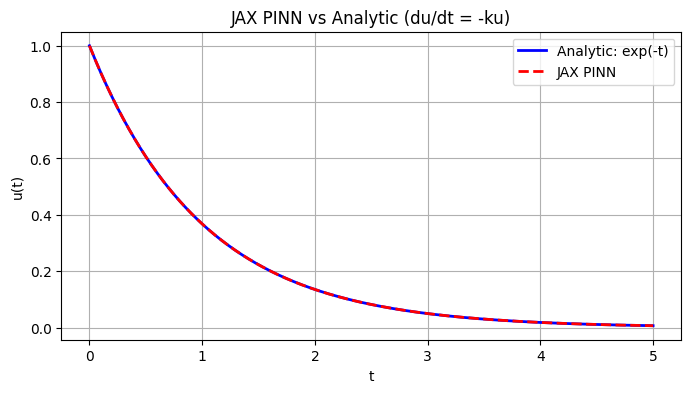

MSE vs analytic: 2.65e-09


In [ ]:
t_eval = jnp.linspace(0, T_END, 500)

# vmap over evaluation points
u_batch = jax.vmap(u, in_axes=(None, 0))
u_pred = np.array(u_batch(params, t_eval))
u_analytic = np.exp(-k * np.array(t_eval))

plt.figure(figsize=(8, 4))
plt.plot(t_eval, u_analytic, 'b-', linewidth=2, label='Analytic: exp(-t)')
plt.plot(t_eval, u_pred, 'r--', linewidth=2, label='JAX PINN')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('JAX PINN vs Analytic (du/dt = -ku)')
plt.legend()
plt.grid(True)
plt.show()

mse = np.mean((u_pred - u_analytic) ** 2)
print(f'MSE vs analytic: {mse:.2e}')

# 6. Plot Loss History

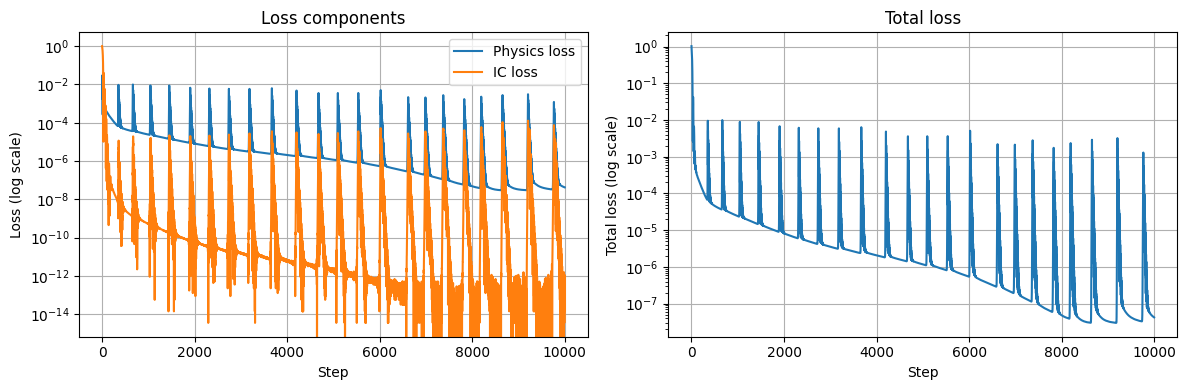

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].semilogy(history['physics'], label='Physics loss')
axes[0].semilogy(history['ic'], label='IC loss')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Loss components')
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(history['total'])
axes[1].set_xlabel('Step')
axes[1].set_ylabel('Total loss (log scale)')
axes[1].set_title('Total loss')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# 8. Extension: PDE in JAX

## 📌 Sai số PDE (PDE Residual) là gì?

Trong PINN, **Sai số PDE** đóng vai trò là **"ràng buộc vật lý"**, bắt mạng thần kinh phải tuân thủ các định luật tự nhiên thay vì chỉ học vẹt dữ liệu.

---

### 1. Bản chất Toán học
Giả sử mạng thần kinh dự đoán nghiệm là $u(x,t)$. Khi thế vào phương trình truyền nhiệt, ta có:

$$\text{Residual} = \frac{\partial u}{\partial t} - \alpha \frac{\partial^2 u}{\partial x^2}$$

* **Bằng 0:** Mạng thần kinh tuân thủ tuyệt đối định luật vật lý.
* **Khác 0:** Giá trị chênh lệch chính là **Sai số PDE** (mức độ "phá luật" của mô hình).

---

### 2. Ý nghĩa cốt lõi trong Huấn luyện
* **Thay thế dữ liệu nhãn ($y_{true}$):** PINN không cần biết trước nghiệm chính xác ở không gian bên trong. Sai số PDE tự đóng vai trò làm hàm phạt (Loss function).
* **Cơ chế hoạt động:** Ta rải ngẫu nhiên các điểm (collocation points), tính sai số PDE tại đó và ép $\text{Loss}_{PDE} = \text{mean}(\text{Residual}^2) \rightarrow 0$.
* **Kết quả:** Quá trình tối ưu hóa sẽ tự động "uốn nắn" trọng số mô hình khớp hoàn toàn với quy luật vật lý, giúp PINN tự giải phương trình vi phân mà không cần các phương pháp chia lưới truyền thống.

In [ ]:
# =====================================================================
# 1. ĐỊNH NGHĨA MÔ HÌNH MẠNG NƠ-RON ĐƠN GIẢN (Giả lập cấu trúc u)
# =====================================================================
# Giả sử mô hình nhận vào (x, t) và trả về một giá trị vô hướng (scalar)
# Trong thực tế, bạn sẽ dùng Flax để áp dụng mô hình MLP. Ở đây ta làm mẫu bằng một hàm:
def u_mock(params, x, t):
    w1, w2, b = params
    # Hàm mẫu phi tuyến để test đạo hàm: u = sin(w1*x) * exp(w2*t) + b
    return jnp.sin(w1 * x) * jnp.exp(w2 * t) + b

# Khởi tạo tham số mẫu (w1, w2, b)
params = (jnp.array(2.0), jnp.array(-0.5), jnp.array(0.1))

# =====================================================================
# 2. XÂY DỰNG PHẦN DƯ VẬT LÝ CHO MỘT ĐIỂM ĐƠN LẺ (x, t)
# =====================================================================
def heat_residual_single(params, x, t, alpha=0.01):
    """Tính phần dư vật lý u_t - alpha * u_xx tại DUY NHẤT một điểm (x, t)."""

    # u_t: Đạo hàm bậc nhất theo t (đối số vị trí số 2)
    u_t = jax.grad(u_mock, argnums=2)(params, x, t)

    # u_x: Đạo hàm bậc nhất theo x (đối số vị trí số 1)
    u_x_fn = lambda x_val: jax.grad(u_mock, argnums=1)(params, x_val, t)

    # u_xx: Đạo hàm bậc hai theo x bằng cách lấy đạo hàm của hàm u_x_fn
    u_xx = jax.grad(u_x_fn)(x)

    # Tính phần dư vật lý (Theo lý thuyết, đại lượng này phải hội tụ về 0)
    residual = u_t - alpha * u_xx
    return residual

# =====================================================================
# 3. VMAP TRÊN TOÀN BỘ CÁC CẶP ĐIỂM CẤU TRÚC (Collocation Points)
# =====================================================================
# Cấu hình in_axes: (None, 0, 0) -> Giữ nguyên params, cắt lát mảng x và mảng t đồng thời dọc theo trục 0
heat_residual_batched = jax.vmap(heat_residual_single, in_axes=(None, 0, 0, None))

# Biên dịch JIT để tối ưu hóa toàn bộ đồ thị tính toán đạo hàm bậc cao
heat_residual_jit = jax.jit(heat_residual_batched)

# =====================================================================
# 4. CHẠY THỬ NGHIỆM VỚI TẬP DỮ LIỆU BATCH
# =====================================================================
# Sinh ngẫu nhiên 500 điểm cấu trúc (collocation points) trong miền không-thời gian
N_points = 500
key = jax.random.PRNGKey(0)
key_x, key_t = jax.random.split(key, 2)

x_collocations = jax.random.uniform(key_x, (N_points,), minval=-1.0, maxval=1.0) # x thuộc [-1, 1]
t_collocations = jax.random.uniform(key_t, (N_points,), minval=0.0, maxval=2.0)  # t thuộc [0, 2]

# Hệ số khuếch tán nhiệt độ alpha
alpha_val = 0.02

# Tính toán phần dư vật lý song song siêu tốc trên GPU/CPU cho cả 500 điểm
residuals = heat_residual_jit(params, x_collocations, t_collocations, alpha_val)

print(f"Kích thước mảng phần dư (Residuals shape): {residuals.shape}")
print(f"Giá trị phần dư tại 5 điểm đầu tiên:      {residuals[:5]}")

Kích thước mảng phần dư (Residuals shape): (500,)
Giá trị phần dư tại 5 điểm đầu tiên:      [-0.4085085   0.39290807  0.20833927  0.29206437  0.317017  ]


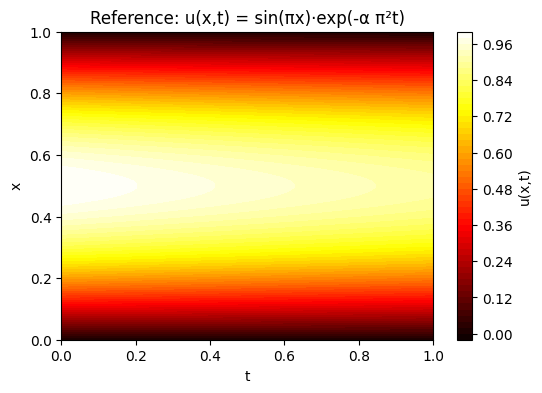

In [ ]:
# Cấu hình seed ngẫu nhiên cho JAX
key = jax.random.PRNGKey(42)
alpha = 0.01  # thermal diffusivity

def analytic_solution(x, t, alpha):
    return jnp.sin(jnp.pi * x) * jnp.exp(-alpha * jnp.pi**2 * t)

# Visualize on a grid (Sử dụng numpy thông thường để vẽ hình)
x_grid = np.linspace(0, 1, 100)
t_grid = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_grid, t_grid)
U_ref = analytic_solution(X, T, alpha)

plt.figure(figsize=(6, 4))
plt.contourf(T, X, U_ref, levels=50, cmap='hot')
plt.colorbar(label='u(x,t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Reference: u(x,t) = sin(πx)·exp(-α π²t)')
plt.show()



In [ ]:
# --- Định nghĩa mô hình mạng thần kinh bằng Flax Linen ---
class PINN(nn.Module):
    hidden: int = 64
    n_layers: int = 4

    @nn.compact
    def __call__(self, xt):
        # xt có dạng [x, t] cho 1 điểm duy nhất
        out = xt
        for _ in range(self.n_layers):
            # Sửa từ nn.Linear thành nn.Dense
            out = nn.Dense(features=self.hidden)(out)
            out = nn.tanh(out)
        # Sửa từ nn.Linear thành nn.Dense
        out = nn.Dense(features=1)(out)
        return out[0]  # Trả về một scalar u(x,t)

# Khởi tạo mô hình và các tham số (params)
model = PINN(hidden=64, n_layers=4)
key, init_key = jax.random.split(key)
dummy_input = jnp.zeros((2,))  # Input thử nghiệm cho 1 điểm đơn lẻ [x, t]
params = model.init(init_key, dummy_input)['params']

In [ ]:
# --- Khởi tạo dữ liệu điểm (Collocation, BC, IC) ---
N_COLLOC = 2000
N_BC = 200
N_IC = 200

key, k1, k2, k3, k4 = jax.random.split(key, 5)

# Interior
x_c = jax.random.uniform(k1, (N_COLLOC, 1), minval=0.0, maxval=1.0)
t_c = jax.random.uniform(k2, (N_COLLOC, 1), minval=0.0, maxval=1.0)
xt_colloc = jnp.concatenate([x_c, t_c], axis=1)

# BC
t_bc = jax.random.uniform(k3, (N_BC, 1), minval=0.0, maxval=1.0)
xt_bc0 = jnp.concatenate([jnp.zeros((N_BC, 1)), t_bc], axis=1)  # x=0
xt_bc1 = jnp.concatenate([jnp.ones((N_BC, 1)), t_bc], axis=1)   # x=1

# IC
x_ic = jax.random.uniform(k4, (N_IC, 1), minval=0.0, maxval=1.0)
xt_ic = jnp.concatenate([x_ic, jnp.zeros((N_IC, 1))], axis=1)
u_ic = jnp.sin(jnp.pi * x_ic).flatten()


# --- Tính toán đạo hàm PDE sử dụng jax.grad ---
def pde_residual_single(params, xt, alpha):
    """Tính toán sai số PDE cho duy nhất 1 điểm xt = [x, t]"""
    # Hàm tính u(x,t) từ params và xt bằng mô hình Flax
    u_fn = lambda _xt: model.apply({'params': params}, _xt)

    # jax.grad tính đạo hàm bậc 1 của u_fn theo biến đầu vào thứ nhất (_xt)
    grad_u = jax.grad(u_fn)

    # Đạo hàm bậc hai theo x: đạo hàm của u_x (phần tử thứ 0 của grad_u) theo xt
    u_xx = jax.grad(lambda _xt: grad_u(_xt)[0])(xt)[0]

    # u_t là phần tử thứ 1 của đạo hàm bậc 1
    u_t = grad_u(xt)[1]

    return u_t - alpha * u_xx

# Sử dụng jax.vmap để tự động vector hóa hàm tính residual cho cả batch dữ liệu
pde_residual_batch = jax.vmap(pde_residual_single, in_axes=(None, 0, None))

In [ ]:
# Hàm dự đoán u cho cả batch (Sử dụng cho BC, IC và Evaluation)
model_batch = jax.vmap(lambda p, x: model.apply({'params': p}, x), in_axes=(None, 0))


# --- Hàm Loss và Bước Cập Nhật ---
W_PDE = 1.0
W_BC = 10.0
W_IC = 1000.0

def loss_fn(params, xt_colloc, xt_bc0, xt_bc1, xt_ic, u_ic, alpha):
    # 1. PDE loss
    res = pde_residual_batch(params, xt_colloc, alpha)
    loss_pde = jnp.mean(res**2)

    # 2. BC loss
    u_pred_bc0 = model_batch(params, xt_bc0)
    u_pred_bc1 = model_batch(params, xt_bc1)
    loss_bc = jnp.mean(u_pred_bc0**2) + jnp.mean(u_pred_bc1**2)

    # 3. IC loss
    u_pred_ic = model_batch(params, xt_ic)
    loss_ic = jnp.mean((u_pred_ic - u_ic)**2)

    total_loss = W_PDE * loss_pde + W_BC * loss_bc + W_IC * loss_ic
    return total_loss

# Khởi tạo Optimizer bằng Optax
optimizer = optax.adam(learning_rate=1e-3)
opt_state = optimizer.init(params)

# Sử dụng jax.jit để tối ưu hóa tốc độ chạy vòng lặp huấn luyện
@jax.jit
def step_fn(params, opt_state, xt_colloc, xt_bc0, xt_bc1, xt_ic, u_ic, alpha):
    # jax.value_and_grad tự động tính cả giá trị loss và gradient theo `params`
    loss, grads = jax.value_and_grad(loss_fn)(params, xt_colloc, xt_bc0, xt_bc1, xt_ic, u_ic, alpha)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


# --- Vòng lặp huấn luyện (Training Loop) ---
N_STEPS = 20000
for step in range(N_STEPS):
    params, opt_state, loss = step_fn(
        params, opt_state, xt_colloc, xt_bc0, xt_bc1, xt_ic, u_ic, alpha
    )

    if (step + 1) % 2000 == 0:
        print(f"Step {step+1}/{N_STEPS}  Loss: {loss:.6f}")

Step 2000/20000  Loss: 0.000090
Step 4000/20000  Loss: 0.000176
Step 6000/20000  Loss: 0.000195
Step 8000/20000  Loss: 0.000172
Step 10000/20000  Loss: 0.000562
Step 12000/20000  Loss: 0.000105
Step 14000/20000  Loss: 0.001038
Step 16000/20000  Loss: 0.000088
Step 18000/20000  Loss: 0.002242
Step 20000/20000  Loss: 0.000104


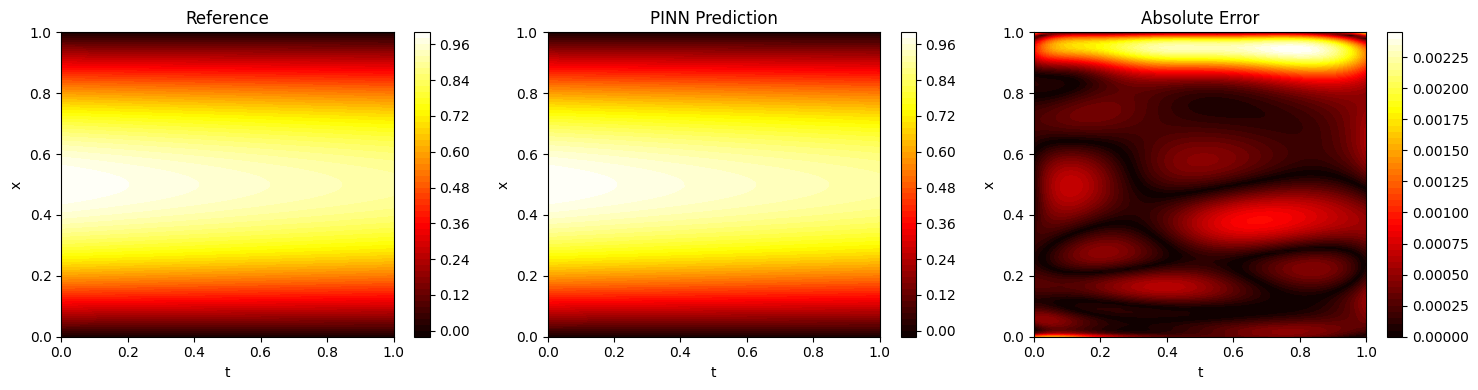

Max absolute error: 0.0024
Mean absolute error: 0.0004


In [ ]:
# --- Đánh giá kết quả (Evaluation) ---
x_eval = jnp.linspace(0, 1, 100)
t_eval = jnp.linspace(0, 1, 100)
X_ev, T_ev = jnp.meshgrid(x_eval, t_eval, indexing='xy')
xt_eval = jnp.stack([X_ev.flatten(), T_ev.flatten()], axis=1)

# Dự đoán bằng PINN (Flax)
U_pred = model_batch(params, xt_eval).reshape(100, 100)
U_ref_jax = analytic_solution(X_ev, T_ev, alpha)
error = jnp.abs(U_pred - U_ref_jax)

# Chuyển dữ liệu sang numpy để vẽ đồ thị
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title in zip(axes,
    [U_ref_jax, U_pred, error],
    ['Reference', 'PINN Prediction', 'Absolute Error']):
    im = ax.contourf(np.array(T_ev), np.array(X_ev), np.array(data), levels=50, cmap='hot')
    plt.colorbar(im, ax=ax)
    ax.set_ylabel('x')
    ax.set_xlabel('t')
    ax.set_title(title)
plt.tight_layout()
plt.show()

print(f'Max absolute error: {error.max():.4f}')
print(f'Mean absolute error: {error.mean():.4f}')